---
**Title:** Pipeline Parallelism (PP)

**Category:** pipeline-parallelism

**Difficulty:** Intermediate

**Estimated Time:** 45 min

---

## Overview

What if your model is too big to fit on a single GPU? One natural idea: **split the layers across GPUs**, so each GPU only holds a piece of the model.

That's **Pipeline Parallelism**. This notebook will walk you through it step by step — starting from the simplest version and gradually improving it.

### Prerequisites

- Basic PyTorch (`nn.Module`, `nn.Sequential`)
- Understanding of forward/backward passes
- Recommended: [00 — GPU Communication](00-gpu-communication.ipynb) and [01 — Data Parallelism](01-data-parallelism.ipynb)

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Our visualization helpers
from mp_tutorial.viz import draw_data_flow, draw_naive_vs_pipeline, draw_pipeline_timeline
from mp_tutorial.formatting import info_box, gpu_required_banner, comparison_table, code_reference
from mp_tutorial.distributed import check_gpu_env, simulate_pipeline_stages
import warnings
warnings.filterwarnings("ignore", message="Glyph.*missing from font", category=UserWarning)
from mp_tutorial.fonts import configure_cjk_fonts
configure_cjk_fonts()

check_gpu_env()

✗ No CUDA GPU detected on this machine.

To run GPU-required cells, use a machine with CUDA GPUs (4+ recommended).
See README.md for remote Jupyter setup instructions.


## Concepts & Principles

### Step 1: The Simplest Idea — Split the Layers

Imagine a model with 8 layers and 4 GPUs. The most natural split:

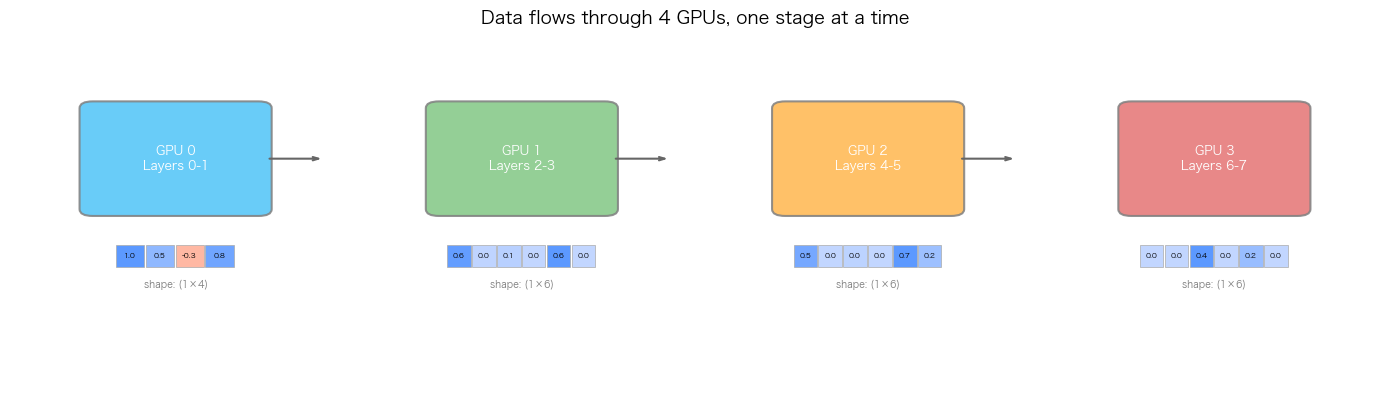

In [2]:
# Let's build a tiny model and watch data flow through it
torch.manual_seed(42)

# A simple 8-layer model (4 stages × 2 layers each)
model = nn.Sequential(
    nn.Linear(4, 6), nn.ReLU(),   # Stage 0 (GPU 0)
    nn.Linear(6, 6), nn.ReLU(),   # Stage 1 (GPU 1)
    nn.Linear(6, 6), nn.ReLU(),   # Stage 2 (GPU 2)
    nn.Linear(6, 3), nn.ReLU(),   # Stage 3 (GPU 3)
)

# One small input batch
x = torch.tensor([[1.0, 0.5, -0.3, 0.8]])

# Run through each stage and capture the intermediate tensors
stage_layers = [
    nn.Sequential(model[0], model[1]),  # GPU 0
    nn.Sequential(model[2], model[3]),  # GPU 1
    nn.Sequential(model[4], model[5]),  # GPU 2
    nn.Sequential(model[6], model[7]),  # GPU 3
]

snapshots = [x]
h = x
for stage in stage_layers:
    with torch.no_grad():
        h = stage(h)
    snapshots.append(h)

# Visualize: data flowing through each GPU
draw_data_flow(
    stage_labels=["GPU 0\nLayers 0-1", "GPU 1\nLayers 2-3",
                  "GPU 2\nLayers 4-5", "GPU 3\nLayers 6-7"],
    data_snapshots=snapshots,
    title="Data flows through 4 GPUs, one stage at a time"
)
plt.show()

The input goes to GPU 0, the output of GPU 0 goes to GPU 1, and so on. Simple!

But there's a **big problem**: when GPU 1 is computing, GPUs 0, 2, 3 are all **idle**. Let's see this visually:

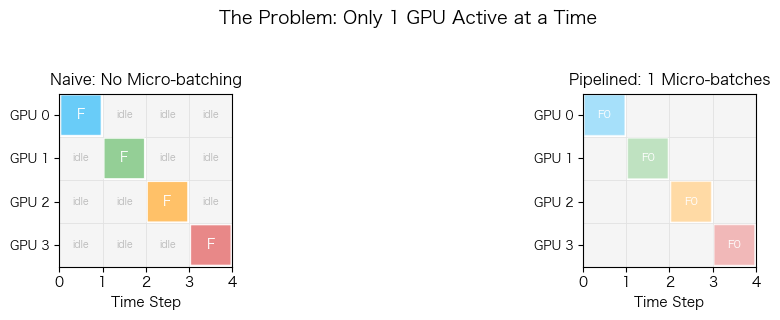

In [3]:
# Left: naive (1 batch, sequential)  vs  Right: with micro-batching
draw_naive_vs_pipeline(num_stages=4, num_microbatches=1, title="The Problem: Only 1 GPU Active at a Time")
plt.show()

With 4 GPUs but only 1 active at a time, we're wasting **75% of our compute**. We need a better idea.

### Step 2: Micro-batching — Fill the Pipeline

The fix: instead of sending one big batch through, **split it into smaller pieces called micro-batches**.

> **What's a micro-batch?** In normal training, you process a "batch" of samples (e.g., 64 images) at once. A *micro-batch* is just that batch chopped into smaller chunks — e.g., 8 micro-batches of 8 images each. The model sees the same data, just in smaller bites.

The key trick: start sending micro-batch #2 into GPU 0 **before** micro-batch #1 has finished going through all GPUs. This way, multiple GPUs work at the same time:

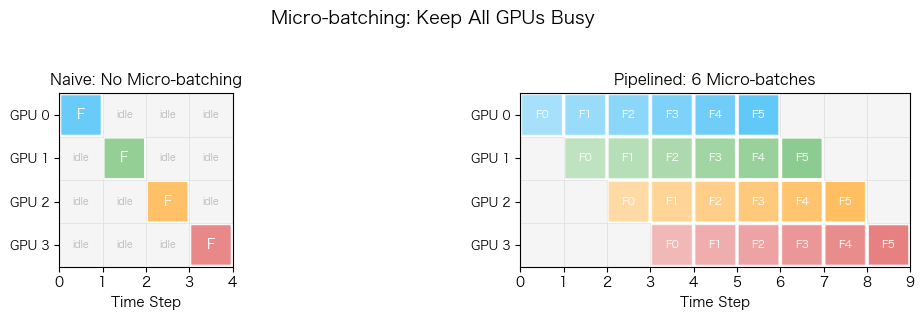

With 4 stages and 6 micro-batches:
  Total time steps:  9
  Bubble (idle) steps per GPU: 3
  Bubble fraction:   3/9 = 33%

→ More micro-batches = less wasted time!


In [4]:
# Now with 6 micro-batches — see how the pipeline fills up!
draw_naive_vs_pipeline(num_stages=4, num_microbatches=6,
                       title="Micro-batching: Keep All GPUs Busy")
plt.show()

# How much time is wasted?
p, m = 4, 6
total = m + p - 1
bubble = p - 1
print(f"With {p} stages and {m} micro-batches:")
print(f"  Total time steps:  {total}")
print(f"  Bubble (idle) steps per GPU: {bubble}")
print(f"  Bubble fraction:   {bubble}/{total} = {bubble/total:.0%}")
print(f"\n→ More micro-batches = less wasted time!")

The gray cells are the **pipeline bubble** — time where a GPU sits idle, waiting for data to arrive or results to propagate.

> **Why "bubble"?** Think of air bubbles in a water pipe — they're gaps where no useful work flows through. In a pipeline, bubbles are the time steps where a GPU has nothing to do.

The bubble fraction formula is:

$$\text{bubble fraction} = \frac{p - 1}{m + p - 1}$$

where $p$ = stages (GPUs), $m$ = micro-batches. More micro-batches → smaller bubble → better efficiency.

### Step 3: Let's Run It — Simulating a Pipeline on CPU

Let's actually run a model through pipeline stages and see the data flow:

In [5]:
# Build a model and run it through simulated pipeline stages
torch.manual_seed(0)

model = nn.Sequential(
    nn.Linear(4, 8), nn.ReLU(),    # Stage 0
    nn.Linear(8, 8), nn.ReLU(),    # Stage 1
    nn.Linear(8, 8), nn.ReLU(),    # Stage 2
    nn.Linear(8, 3), nn.ReLU(),    # Stage 3
)

# Split a batch of 12 samples into 4 micro-batches of 3
batch = torch.randn(12, 4)
micro_batches = list(batch.chunk(4))

print(f"Original batch: {batch.shape} → split into {len(micro_batches)} micro-batches of {micro_batches[0].shape}\n")

outputs = simulate_pipeline_stages(model, num_stages=4, micro_batches=micro_batches)

Original batch: torch.Size([12, 4]) → split into 4 micro-batches of torch.Size([3, 4])

Pipeline: 8 layers split into 4 stages
  Stage 0: 2 layer(s)
  Stage 1: 2 layer(s)
  Stage 2: 2 layer(s)
  Stage 3: 2 layer(s)

=== Forward Pass ===
  [t= 0] Stage 0 processes micro-batch 0 → shape (3, 8)
  [t= 1] Stage 1 processes micro-batch 0 → shape (3, 8)
  [t= 2] Stage 2 processes micro-batch 0 → shape (3, 8)
  [t= 3] Stage 3 processes micro-batch 0 → shape (3, 3)
  [t= 1] Stage 0 processes micro-batch 1 → shape (3, 8)
  [t= 2] Stage 1 processes micro-batch 1 → shape (3, 8)
  [t= 3] Stage 2 processes micro-batch 1 → shape (3, 8)
  [t= 4] Stage 3 processes micro-batch 1 → shape (3, 3)
  [t= 2] Stage 0 processes micro-batch 2 → shape (3, 8)
  [t= 3] Stage 1 processes micro-batch 2 → shape (3, 8)
  [t= 4] Stage 2 processes micro-batch 2 → shape (3, 8)
  [t= 5] Stage 3 processes micro-batch 2 → shape (3, 3)
  [t= 3] Stage 0 processes micro-batch 3 → shape (3, 8)
  [t= 4] Stage 1 processes micro-ba

## Visual Illustrations

Now let's look at the different **scheduling strategies** that have been invented to make pipelines more efficient.

> **Important assumption:** In practice, the backward pass takes roughly **2x the compute of the forward pass** (it must compute both the gradient of the loss w.r.t. activations AND the gradient w.r.t. weights). All diagrams below reflect this: **forward blocks are 1 unit wide, backward blocks are 2 units wide**.

### GPipe Schedule

The simplest approach: run **all forward passes** first, then **all backward passes**.

Look at the schedule grid below — each colored block is a micro-batch being processed. Gray = bubble (idle).

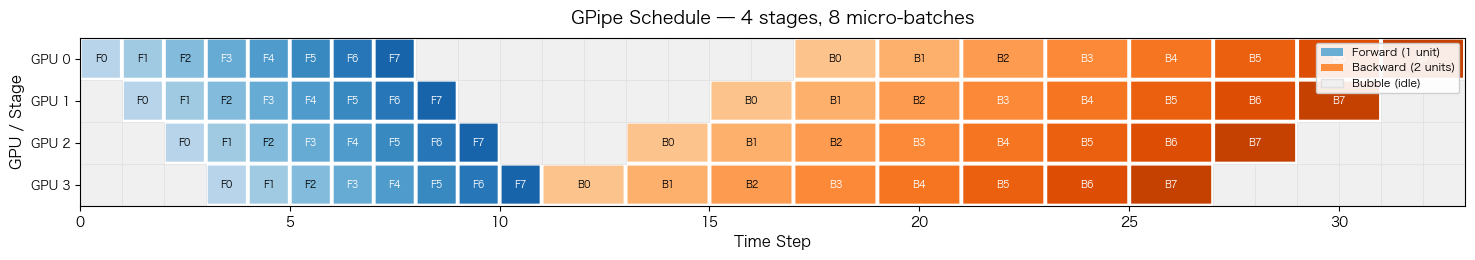

In [6]:
# GPipe: all forwards, then all backwards
fig, ax = draw_pipeline_timeline(num_stages=4, num_microbatches=8, schedule="gpipe")
plt.show()

info_box(
    "GPipe is simple but uses a lot of memory: it must store <b>activations</b> for "
    "ALL 8 micro-batches at once (needed for the backward pass later). "
    "<br><br>"
    "<b>What are activations?</b> During the forward pass, each layer produces "
    "intermediate outputs (activations). These must be kept in memory because the "
    "backward pass needs them to compute gradients. More micro-batches in flight "
    "= more activations stored = more GPU memory used."
    "<br><br>"
    "Memory cost: O(m) where m = micro-batches.",
    title="GPipe Memory"
)

### 1F1B Schedule (One Forward, One Backward)

GPipe's problem: it holds activations for **all** micro-batches simultaneously, because backward passes don't start until all forwards are done. Can we do better?

The idea behind 1F1B: **start backward passes as early as possible** to release memory. Specifically, once the **last stage** finishes a forward pass, it immediately does the backward pass for that same micro-batch. This backward result then propagates up to earlier stages.

The schedule has **three distinct phases**:

#### Phase 1: Warmup (fill the pipeline)
Each stage does only forward passes — there's nothing to backward yet. The pipeline gradually fills up as micro-batches flow from stage 0 → 1 → 2 → 3.

#### Phase 2: Steady State (the "1F1B" pattern)
The last stage alternates: **one forward, one backward**. Each backward frees the activations from one micro-batch. This "pressure wave" of backward passes propagates upward, so earlier stages also enter 1F1B mode.

#### Phase 3: Cooldown (drain the pipeline)
No new forward passes — only backward passes remain. Each stage completes its remaining backwards.

The key insight: by interleaving forward and backward, each stage only holds activations for **O(p)** micro-batches at any time, compared to GPipe's **O(m)**. With `p=4, m=8`, that's 4 vs 8 — a 2x memory saving!

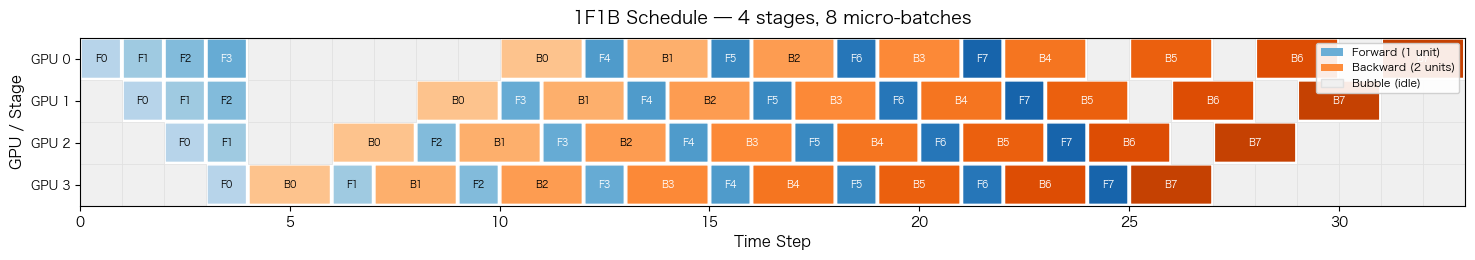

In [7]:
# 1F1B: interleave forward and backward passes
fig, ax = draw_pipeline_timeline(num_stages=4, num_microbatches=8, schedule="1f1b")
plt.show()

info_box(
    "1F1B has the SAME bubble fraction as GPipe, but much less memory! "
    "Each GPU only needs to store activations for O(p) micro-batches "
    "(the ones currently in-flight), not all m. "
    "With p=4: memory drops from O(8) to O(4).",
    title="1F1B Advantage"
)

Look at GPU 3 (last stage) in the 1F1B diagram above — you can see the three phases clearly:

```
GPU 3:  [F0] [B0  B0] [F1] [B1  B1] [F2] [B2  B2] ... [F7] [B7  B7]
         ↑              ↑                                      ↑
      warmup         steady state (1 fwd + 1 bwd)          cooldown
```

Now look at GPU 0 (first stage): it does *more* warmup forwards before entering 1F1B mode, because it takes time for backward signals to propagate back from GPU 3.

**Same bubble, less memory** — that's the 1F1B trade-off. The bubble fraction is identical to GPipe, but the peak memory per GPU drops from O(m) to O(p).

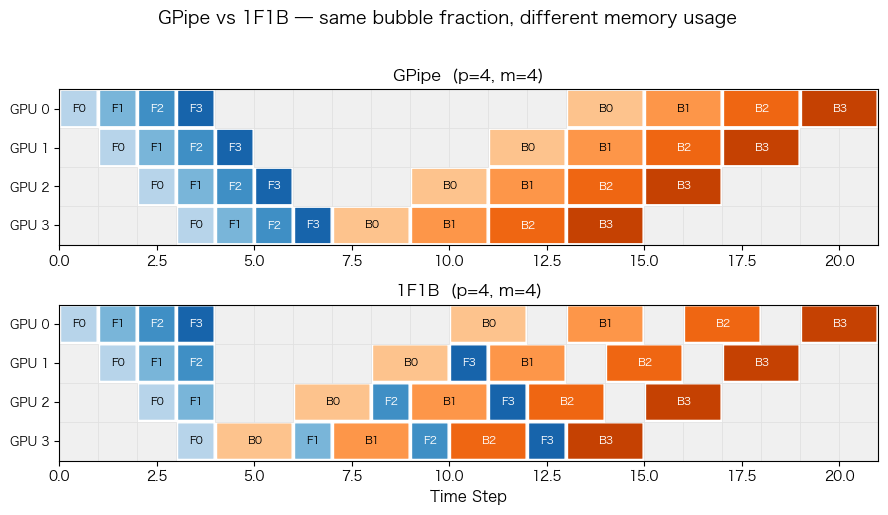

In [8]:
# Side-by-side: GPipe vs 1F1B (4 stages, 4 micro-batches for clarity)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5))

from mp_tutorial.viz import _generate_gpipe_schedule, _generate_1f1b_schedule
import matplotlib.patches as mpatches

for ax, sched_fn, name in [(ax1, _generate_gpipe_schedule, "GPipe"),
                             (ax2, _generate_1f1b_schedule, "1F1B")]:
    sched = sched_fn(4, 4)
    fwd_cmap, bwd_cmap = plt.cm.Blues, plt.cm.Oranges
    max_time = max(t + d for t, _, _, _, d in sched)

    occupied = set()
    for t, s, m, kind, dur in sched:
        color_val = 0.3 + 0.5 * (m % 4) / 3
        color = fwd_cmap(color_val) if kind == "fwd" else bwd_cmap(color_val)
        rect = mpatches.FancyBboxPatch((t + 0.05, s + 0.05), dur - 0.1, 0.9,
            boxstyle="round,pad=0.02", facecolor=color, edgecolor="white", lw=1)
        ax.add_patch(rect)
        label = f"{'F' if kind == 'fwd' else 'B'}{m}"
        ax.text(t + dur / 2, s + 0.5, label, ha="center", va="center",
                fontsize=8, fontweight="bold", color="white" if color_val > 0.5 else "black")
        for dt in range(dur):
            occupied.add((t + dt, s))

    for t in range(max_time):
        for s in range(4):
            if (t, s) not in occupied:
                ax.add_patch(mpatches.Rectangle((t, s), 1, 1, fc="#f0f0f0", ec="#e0e0e0", lw=0.5))

    ax.set_xlim(0, max_time)
    ax.set_ylim(0, 4)
    ax.invert_yaxis()
    ax.set_yticks([s + 0.5 for s in range(4)])
    ax.set_yticklabels([f"GPU {s}" for s in range(4)], fontsize=9)
    ax.set_title(f"{name}  (p=4, m=4)", fontsize=12, fontweight="bold")
    ax.set_aspect("equal")

ax2.set_xlabel("Time Step", fontsize=11)
fig.suptitle("GPipe vs 1F1B — same bubble fraction, different memory usage",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

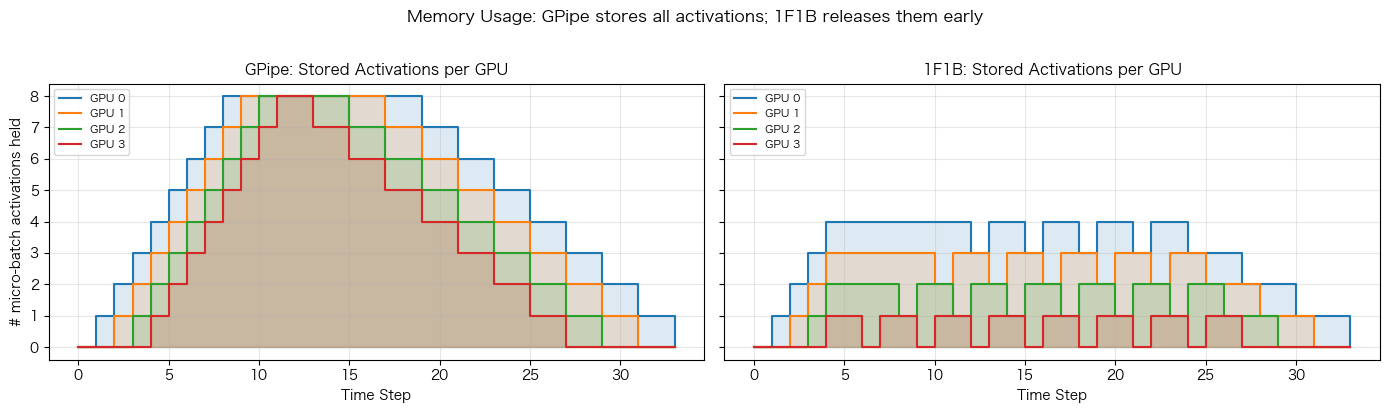

GPipe peak: each stage holds up to 8 micro-batch activations (all of them)
1F1B peak:  each stage holds at most ~4 micro-batch activations (p = num_stages)


In [9]:
# Memory comparison: how many activations does each GPU hold over time?
# In GPipe, forward activations accumulate until backward starts.
# In 1F1B, backward passes release activations early.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, sched_fn, name in [(ax1, _generate_gpipe_schedule, "GPipe"),
                             (ax2, _generate_1f1b_schedule, "1F1B")]:
    sched = sched_fn(4, 8)
    max_time = max(t + d for t, _, _, _, d in sched)

    # Track active micro-batch activations per stage over time
    for s in range(4):
        # At each time t, count: #forwards completed - #backwards completed
        fwd_events = sorted([(t + dur, +1) for t, s2, m, kind, dur in sched if s2 == s and kind == "fwd"])
        bwd_events = sorted([(t + dur, -1) for t, s2, m, kind, dur in sched if s2 == s and kind == "bwd"])
        events = sorted(fwd_events + bwd_events)

        times = [0]
        counts = [0]
        count = 0
        for time, delta in events:
            times.append(time)
            counts.append(count)
            count += delta
            times.append(time)
            counts.append(count)
        times.append(max_time)
        counts.append(count)

        ax.fill_between(times, counts, alpha=0.15, color=f"C{s}")
        ax.plot(times, counts, label=f"GPU {s}", linewidth=1.5, color=f"C{s}")

    ax.set_xlabel("Time Step", fontsize=10)
    ax.set_title(f"{name}: Stored Activations per GPU", fontsize=11, fontweight="bold")
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(alpha=0.3)

ax1.set_ylabel("# micro-batch activations held", fontsize=10)
fig.suptitle("Memory Usage: GPipe stores all activations; 1F1B releases them early",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("GPipe peak: each stage holds up to 8 micro-batch activations (all of them)")
print("1F1B peak:  each stage holds at most ~4 micro-batch activations (p = num_stages)")

### Comparing the Schedules

Let's put the key differences side by side:

In [10]:
p, m = 4, 8
comparison_table(
    headers=["Schedule", "Bubble Fraction", "Peak Memory", "Complexity"],
    rows=[
        ["Naive (no micro-batch)", f"{(p-1)/p:.0%}", "O(1)", "Trivial"],
        ["GPipe", f"{(p-1)/(m+p-1):.0%}", "O(m) = O(8)", "Simple"],
        ["1F1B", f"{(p-1)/(m+p-1):.0%}", "O(p) = O(4)", "Moderate"],
        ["Interleaved (v=2)", f"{(p-1)/(2*m+p-1):.0%}", "O(p) = O(4)", "Complex"],
    ],
    title=f"Pipeline Schedules Compared (p={p} stages, m={m} micro-batches)"
)

Schedule,Bubble Fraction,Peak Memory,Complexity
Naive (no micro-batch),75%,O(1),Trivial
GPipe,27%,O(m) = O(8),Simple
1F1B,27%,O(p) = O(4),Moderate
Interleaved (v=2),16%,O(p) = O(4),Complex


### Interleaved Virtual Stages (Advanced)

Megatron-LM's trick: give each GPU **multiple non-contiguous layer groups** (virtual stages). This reduces the bubble further.

For example, with 4 GPUs and 2 virtual stages each:
- GPU 0: Layers 0–1 **and** Layers 8–9
- GPU 1: Layers 2–3 **and** Layers 10–11
- ...

The bubble fraction drops to: $\frac{p-1}{v \cdot m + p-1}$ (where $v$ = virtual stages per GPU). The trade-off is more communication — data passes through each GPU $v$ times.

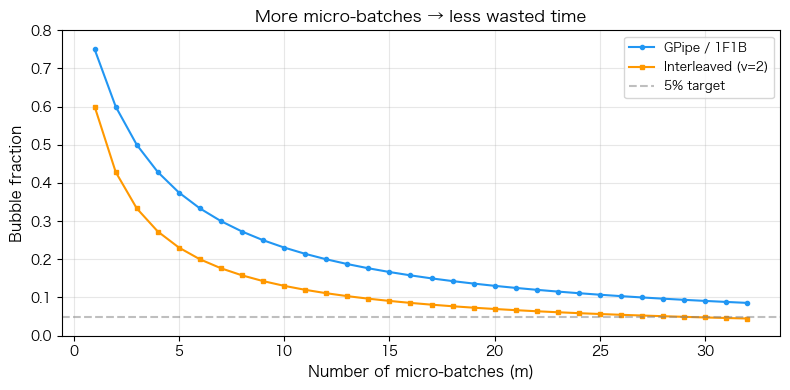

In [11]:
# How bubble fraction changes with more micro-batches
stages = 4
ms = range(1, 33)
bubble_gpipe = [(stages - 1) / (m + stages - 1) for m in ms]
bubble_interleaved = [(stages - 1) / (2 * m + stages - 1) for m in ms]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(ms), bubble_gpipe, 'o-', color="#2196F3", label="GPipe / 1F1B", markersize=3)
ax.plot(list(ms), bubble_interleaved, 's-', color="#FF9800", label="Interleaved (v=2)", markersize=3)
ax.axhline(y=0.05, color='gray', linestyle='--', alpha=0.5, label="5% target")
ax.set_xlabel("Number of micro-batches (m)", fontsize=11)
ax.set_ylabel("Bubble fraction", fontsize=11)
ax.set_title("More micro-batches → less wasted time", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, 0.8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Application in LLMs

Pipeline parallelism is used in all the largest language models:

- **GPT-3 (175B):** 8-way PP × 8-way TP across 64 GPUs. PP handles inter-node communication (cheaper: only point-to-point between adjacent stages)
- **Megatron-Turing NLG (530B):** 8 PP × 8 TP × 35 DP = 2240 GPUs, with interleaved scheduling
- **General rule:** TP within a node (fast NVLink), PP across nodes (only needs point-to-point), DP across replicas

> **Jargon check:**
> - *Node* = one physical server, usually with 8 GPUs connected by fast **NVLink** (600+ GB/s)
> - *Inter-node* = communication between servers, over slower network (InfiniBand, ~400 GB/s)
> - *AllReduce* = every GPU sends data to every other GPU (expensive). *Point-to-point* = only send to your neighbor (cheap)
> - That's why PP is preferred between nodes — it only talks to the next/previous stage!

In [12]:
# Why PP is preferred for inter-node communication
comparison_table(
    headers=["Parallelism", "Communication Pattern", "Best For"],
    rows=[
        ["Data Parallel (DP)", "AllReduce (all GPUs talk to all)", "Many replicas, same model"],
        ["Tensor Parallel (TP)", "AllReduce within each layer", "Within a node (fast NVLink)"],
        ["Pipeline Parallel (PP)", "Point-to-point (adjacent stages only)", "Across nodes (slower network)"],
    ],
    title="Why PP is the go-to for cross-node parallelism"
)

Parallelism,Communication Pattern,Best For
Data Parallel (DP),AllReduce (all GPUs talk to all),"Many replicas, same model"
Tensor Parallel (TP),AllReduce within each layer,Within a node (fast NVLink)
Pipeline Parallel (PP),Point-to-point (adjacent stages only),Across nodes (slower network)


## Hands-on Code

### GPU-Required: Real Pipeline Training with PyTorch Pipe

In [13]:
gpu_required_banner()

In [ ]:
# [GPU-REQUIRED]
# Save as pp_train.py and run: torchrun --nproc_per_node=4 pp_train.py

"""
import torch
import torch.nn as nn
from torch.distributed.pipeline.sync import Pipe

# Place layers on different GPUs
model = nn.Sequential(
    nn.Linear(256, 512).cuda(0), nn.ReLU().cuda(0),
    nn.Linear(512, 512).cuda(1), nn.ReLU().cuda(1),
    nn.Linear(512, 256).cuda(2), nn.ReLU().cuda(2),
    nn.Linear(256, 10).cuda(3),
)

# Pipe handles micro-batch splitting automatically
pipe_model = Pipe(model, chunks=8)

optimizer = torch.optim.Adam(pipe_model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

for step in range(10):
    x = torch.randn(32, 256).cuda(0)
    target = torch.randint(10, (32,)).cuda(3)

    out = pipe_model(x)
    loss = loss_fn(out.local_value(), target)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    print(f"Step {step}: loss={loss.item():.4f}")
"""
print("See code above — run with: torchrun --nproc_per_node=4 pp_train.py")

## Megatron Reference

Megatron-LM's pipeline scheduling lives in `megatron/core/pipeline_parallel/schedules.py`. Here are the two key functions:

In [14]:
code_reference(
    code="""def forward_backward_pipelining_without_interleaving(...):
    # 1F1B Schedule
    # Phase 1: Warmup — fill pipeline with forward passes
    for i in range(num_warmup_microbatches):
        output = forward_step(...)
        send_forward(output)

    # Phase 2: Steady state — alternate 1 forward, 1 backward
    for i in range(num_microbatches_remaining):
        output = forward_step(...)
        send_forward(output)
        grad = backward_step(...)
        send_backward(grad)

    # Phase 3: Cooldown — drain remaining backward passes
    for i in range(num_warmup_microbatches):
        grad = backward_step(...)
        send_backward(grad)""",
    source="Megatron-LM",
    filepath="megatron/core/pipeline_parallel/schedules.py"
)

## Summary & Further Reading

### Key Takeaways

1. **Pipeline Parallelism** splits model layers across GPUs — each GPU holds a "stage"
2. Without micro-batching, only 1 GPU works at a time — terrible utilization
3. **Micro-batching** fills the pipeline: split batch into $m$ parts, overlap computation
4. **Bubble fraction** $= \frac{p-1}{m+p-1}$ — use $m \gg p$ to minimize waste
5. **GPipe**: simple (all-fwd then all-bwd), but high memory ($O(m)$)
6. **1F1B**: same bubble, but lower memory ($O(p)$) by interleaving fwd/bwd
7. **Interleaved stages**: reduce bubble further by $v\times$, at cost of more communication

### Pushing Bubbles to Near-Zero

The schedules above all accept some pipeline bubble as inevitable. Recent work from DeepSeek challenges this:

- **Zero Bubble Pipeline Parallelism** (Qi et al., 2023) splits the backward pass into two parts — **B** (activation gradients) and **W** (weight gradients) — and schedules them independently. Because the **W** step has no data dependency on upstream stages, it can fill bubble slots that were previously idle. The result: **near-zero bubble overhead** with the same memory footprint as 1F1B.

- **DualPipe** (DeepSeek-V3, 2024) goes further for mixture-of-expert (MoE) models. It overlaps **computation and communication** within each micro-step by splitting each forward/backward into an *attention* phase and a *MoE-dispatch* phase, then bi-directionally filling the pipeline from both ends. DeepSeek-V3 reports effectively **hiding nearly all communication** behind computation, achieving close to full hardware utilization on 2048 GPUs.

These methods represent the current frontier of pipeline scheduling.

### Further Reading

- [GPipe (Huang et al., 2019)](https://arxiv.org/abs/1811.06965) — micro-batch pipeline parallelism
- [PipeDream (Narayanan et al., 2019)](https://arxiv.org/abs/1806.03377) — 1F1B scheduling
- [Efficient Large-Scale Training (Narayanan et al., 2021)](https://arxiv.org/abs/2104.04473) — Megatron-LM interleaved scheduling
- [Zero Bubble Pipeline Parallelism (Qi et al., 2023)](https://arxiv.org/abs/2401.10241) — split B/W scheduling for near-zero bubble
- [DeepSeek-V3 Technical Report (2024)](https://arxiv.org/abs/2412.19437) — DualPipe: bidirectional pipeline with computation-communication overlap
- [PyTorch Pipeline Parallelism](https://pytorch.org/docs/stable/pipeline.html)
- [Megatron-LM](https://github.com/NVIDIA/Megatron-LM) — `megatron/core/pipeline_parallel/`